# Fraud Detection EDA

Comprehensive exploratory data analysis for Credit Card, IEEE-CIS, and PaySim fraud datasets. This notebook follows a professional, chronological workflow: imports, loading, overview, visualization, data quality, cleaning, merging, and export.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load Datasets

In [ ]:
# Paths
creditcard_path = '../data/raw/creditcard.csv'
ieee_identity_path = '../data/raw/ieee/train_identity.csv'
ieee_transaction_path = '../data/raw/ieee/train_transaction.csv'
paysim_path = '../data/raw/paysim/paysim.csv'

# Load
df_credit = pd.read_csv(creditcard_path)
df_ieee_id = pd.read_csv(ieee_identity_path)
df_ieee_tx = pd.read_csv(ieee_transaction_path)
df_paysim = pd.read_csv(paysim_path)

## Initial Data Overview

In [ ]:
# Shapes and columns
for name, df in zip(['CreditCard', 'IEEE Identity', 'IEEE Transaction', 'PaySim'], [df_credit, df_ieee_id, df_ieee_tx, df_paysim]):
    print(f'{name}: shape={df.shape}, columns={df.columns.tolist()}')

## Class Distribution

In [ ]:
# Class distribution
print('CreditCard:', df_credit['Class'].value_counts(normalize=True))
if 'isFraud' in df_ieee_tx.columns:
    print('IEEE Transaction:', df_ieee_tx['isFraud'].value_counts(normalize=True))
if 'isFraud' in df_paysim.columns:
    print('PaySim:', df_paysim['isFraud'].value_counts(normalize=True))

## Visualize Class Distribution

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x='Class', data=df_credit, ax=axs[0])
axs[0].set_title('CreditCard Fraud')
sns.countplot(x='isFraud', data=df_ieee_tx, ax=axs[1])
axs[1].set_title('IEEE Fraud')
sns.countplot(x='isFraud', data=df_paysim, ax=axs[2])
axs[2].set_title('PaySim Fraud')
plt.tight_layout()
plt.show()

## Summary Statistics

In [ ]:
print('CreditCard:')
print(df_credit.describe())
print('IEEE Transaction:')
print(df_ieee_tx.describe())
print('PaySim:')
print(df_paysim.describe())

## Missing Values & Duplicates

In [ ]:
for name, df in zip(['CreditCard', 'IEEE Identity', 'IEEE Transaction', 'PaySim'], [df_credit, df_ieee_id, df_ieee_tx, df_paysim]):
    print(f'
{name} missing values:')
    print(df.isnull().sum().sort_values(ascending=False).head(20))
    print(f'{name} duplicate rows:', df.duplicated().sum())

## Outlier Detection

In [ ]:
for name, df in zip(['CreditCard', 'IEEE Transaction', 'PaySim'], [df_credit, df_ieee_tx, df_paysim]):
    print(f'
{name} outlier summary:')
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        outliers = ((df[col] < (q1 - 1.5 * iqr)) | (df[col] > (q3 + 1.5 * iqr))).sum()
        print(f'{col}: {outliers} outliers')

## Data Cleaning (Example)

In [ ]:
# Remove duplicate rows (if any)
df_credit = df_credit.drop_duplicates()
df_ieee_id = df_ieee_id.drop_duplicates()
df_ieee_tx = df_ieee_tx.drop_duplicates()
df_paysim = df_paysim.drop_duplicates()

## Data Merging & Alignment

In [ ]:
# Merge IEEE identity and transaction data
df_ieee = pd.merge(df_ieee_tx, df_ieee_id, how='left', left_on='TransactionID', right_on='TransactionID')
print('Merged IEEE shape:', df_ieee.shape)

## Unified Fraud Label Creation

In [ ]:
df_credit['isFraud'] = df_credit['Class']
df_paysim['isFraud'] = df_paysim['isFraud'] # already present
df_ieee['isFraud'] = df_ieee['isFraud'] # already present

## Concatenate for Unified Analysis

In [ ]:
common_cols = ['isFraud']
df_all = pd.concat([df_credit[common_cols], df_ieee[common_cols], df_paysim[common_cols]], axis=0, ignore_index=True)
print('Unified dataset shape:', df_all.shape)

## Save Cleaned & Merged Data

In [ ]:
os.makedirs('../data/processed', exist_ok=True)
df_credit.to_csv('../data/processed/creditcard_clean.csv', index=False)
df_ieee.to_csv('../data/processed/ieee_clean.csv', index=False)
df_paysim.to_csv('../data/processed/paysim_clean.csv', index=False)
df_all.to_csv('../data/processed/all_fraud_clean.csv', index=False)

## Next Steps
Proceed to feature engineering and modeling in the next notebook.

# Fraud Detection EDA
Exploratory Data Analysis for Credit Card, IEEE-CIS, and PaySim datasets.

This notebook follows a professional, chronological EDA workflow: imports, loading, overview, visualization, data quality, cleaning, merging, and export.

# Fraud Detection EDA
Exploratory Data Analysis for Credit Card, IEEE-CIS, and PaySim datasets.

In [7]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load Datasets

In [8]:
# Paths
creditcard_path = '../data/raw/creditcard.csv'
ieee_identity_path = '../data/raw/ieee/train_identity.csv'
ieee_transaction_path = '../data/raw/ieee/train_transaction.csv'
paysim_path = '../data/raw/paysim/paysim.csv'

# Load
df_credit = pd.read_csv(creditcard_path)
df_ieee_id = pd.read_csv(ieee_identity_path)
df_ieee_tx = pd.read_csv(ieee_transaction_path)
df_paysim = pd.read_csv(paysim_path)

## Dataset Shapes & Columns

In [9]:
print('CreditCard:', df_credit.shape, df_credit.columns.tolist())
print('IEEE Identity:', df_ieee_id.shape, df_ieee_id.columns.tolist())
print('IEEE Transaction:', df_ieee_tx.shape, df_ieee_tx.columns.tolist())
print('PaySim:', df_paysim.shape, df_paysim.columns.tolist())

CreditCard: (284807, 31) ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
IEEE Identity: (144233, 41) ['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
IEEE Transaction: (590540, 394) ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4'

## Class Distribution

In [10]:
# CreditCard
print(df_credit['Class'].value_counts(normalize=True))
# IEEE
if 'isFraud' in df_ieee_tx.columns:
    print(df_ieee_tx['isFraud'].value_counts(normalize=True))
# PaySim
if 'isFraud' in df_paysim.columns:
    print(df_paysim['isFraud'].value_counts(normalize=True))

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


## Visualize Class Distribution

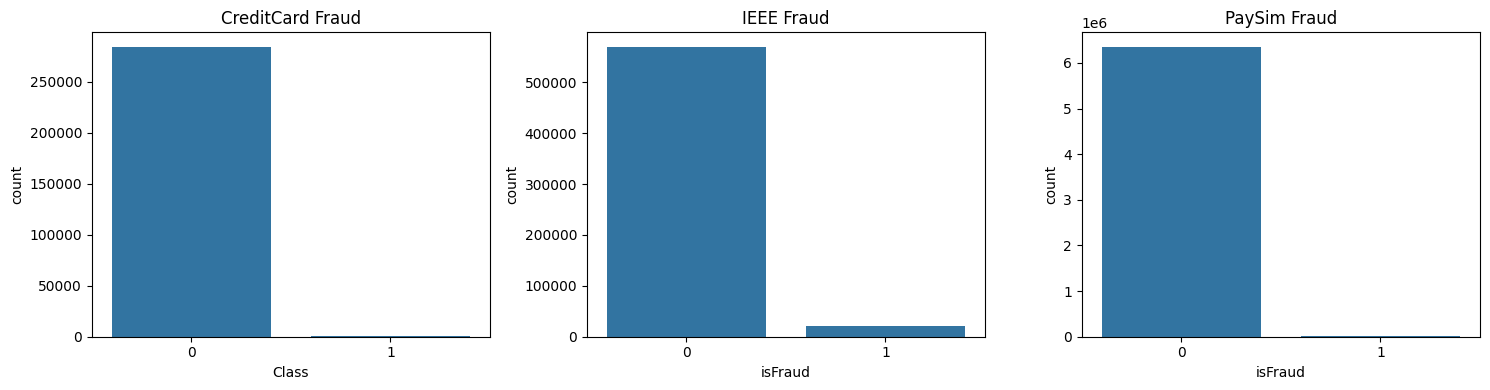

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x='Class', data=df_credit, ax=axs[0])
axs[0].set_title('CreditCard Fraud')
sns.countplot(x='isFraud', data=df_ieee_tx, ax=axs[1])
axs[1].set_title('IEEE Fraud')
sns.countplot(x='isFraud', data=df_paysim, ax=axs[2])
axs[2].set_title('PaySim Fraud')
plt.tight_layout()
plt.show()

## Summary Statistics

In [12]:
print(df_credit.describe())
print(df_ieee_tx.describe())
print(df_paysim.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

## Missing Values & Data Quality Checks
Check for missing values, duplicates, and outliers in each dataset.

In [13]:
# Missing values summary
for name, df in zip(['CreditCard', 'IEEE Identity', 'IEEE Transaction', 'PaySim'], [df_credit, df_ieee_id, df_ieee_tx, df_paysim]):
    print(f'\n{name} missing values:')
    print(df.isnull().sum().sort_values(ascending=False).head(20))


CreditCard missing values:
Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
V21       0
V20       0
V19       0
V18       0
V17       0
V15       0
V1        0
V14       0
V13       0
V12       0
dtype: int64

IEEE Identity missing values:
id_24         139486
id_25         139101
id_07         139078
id_08         139078
id_21         139074
id_26         139070
id_23         139064
id_27         139064
id_22         139064
id_18          99120
id_03          77909
id_04          77909
id_33          70944
id_09          69307
id_10          69307
id_30          66668
id_32          66647
id_34          66428
id_14          64189
DeviceInfo     25567
dtype: int64

IEEE Transaction missing values:
dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V139     508595
V162     508595
V161     508595
V154     508595
V138     5085

In [14]:
# Duplicate rows check
for name, df in zip(['CreditCard', 'IEEE Identity', 'IEEE Transaction', 'PaySim'], [df_credit, df_ieee_id, df_ieee_tx, df_paysim]):
    print(f'\n{name} duplicate rows:', df.duplicated().sum())


CreditCard duplicate rows: 1081

IEEE Identity duplicate rows: 0

IEEE Identity duplicate rows: 0

IEEE Transaction duplicate rows: 0

IEEE Transaction duplicate rows: 0

PaySim duplicate rows: 0

PaySim duplicate rows: 0


In [15]:
# Outlier detection (basic numeric columns)
for name, df in zip(['CreditCard', 'IEEE Transaction', 'PaySim'], [df_credit, df_ieee_tx, df_paysim]):
    print(f'\n{name} outlier summary:')
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        outliers = ((df[col] < (q1 - 1.5 * iqr)) | (df[col] > (q3 + 1.5 * iqr))).sum()
        print(f'{col}: {outliers} outliers')


CreditCard outlier summary:
Time: 0 outliers
V1: 7062 outliers
V2: 13526 outliers
V3: 3363 outliers
V4: 11148 outliers
V5: 12295 outliers
V6: 22965 outliers
V7: 8948 outliers
V8: 24134 outliers
V9: 8283 outliers
V10: 9496 outliers
V11: 780 outliers
V12: 15348 outliers
V13: 3368 outliers
V14: 14149 outliers
V15: 2894 outliers
V16: 8184 outliers
V17: 7420 outliers
V18: 7533 outliers
V19: 10205 outliers
V20: 27770 outliers
V21: 14497 outliers
V22: 1317 outliers
V23: 18541 outliers
V24: 4774 outliers
V25: 5367 outliers
V26: 5596 outliers
V27: 39163 outliers
V28: 30342 outliers
Amount: 31904 outliers
Class: 492 outliers

IEEE Transaction outlier summary:
TransactionID: 0 outliers
isFraud: 20663 outliers
TransactionDT: 0 outliers
TransactionAmt: 66482 outliers
card1: 0 outliers
card2: 0 outliers
card3: 67688 outliers
card5: 0 outliers
addr1: 369 outliers
addr2: 4353 outliers
dist1: 39981 outliers
dist2: 4710 outliers
C1: 59535 outliers
C2: 62214 outliers
C3: 2429 outliers
C4: 138657 outlier

## Data Merging & Alignment
Prepare datasets for merging and alignment.

In [16]:
# Example: Merge IEEE identity and transaction data
df_ieee = pd.merge(df_ieee_tx, df_ieee_id, how='left', left_on='TransactionID', right_on='TransactionID')
print('Merged IEEE shape:', df_ieee.shape)

Merged IEEE shape: (590540, 434)


In [17]:
# Prepare unified fraud label for all datasets
df_credit['isFraud'] = df_credit['Class']
df_paysim['isFraud'] = df_paysim['isFraud'] # already present
df_ieee['isFraud'] = df_ieee['isFraud'] # already present

In [18]:
# Example: Concatenate datasets for unified analysis (minimal columns)
common_cols = ['isFraud']
df_all = pd.concat([df_credit[common_cols], df_ieee[common_cols], df_paysim[common_cols]], axis=0, ignore_index=True)
print('Unified dataset shape:', df_all.shape)

Unified dataset shape: (7237967, 1)


## Save Cleaned & Merged Data
Export cleaned and merged datasets for downstream feature engineering and modeling.

In [19]:
# Save cleaned datasets
os.makedirs('../data/processed', exist_ok=True)
df_credit.to_csv('../data/processed/creditcard_clean.csv', index=False)
df_ieee.to_csv('../data/processed/ieee_clean.csv', index=False)
df_paysim.to_csv('../data/processed/paysim_clean.csv', index=False)
df_all.to_csv('../data/processed/all_fraud_clean.csv', index=False)